In [ ]:
from google.colab import files
uploded=files.upload()

Saving Iris.csv to Iris.csv


In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns




In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("Iris.csv")

In [ ]:
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [ ]:
print(df.describe())

               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


In [ ]:
print(df.isnull().sum())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [ ]:
# Step 9 : Encode Target Variable
# -------------------------------------------------------

encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(df["Species"])

print("\nEncoded Classes")

for i, name in enumerate(encoder.classes_):
    print(i, "=", name)




Encoded Classes
0 = Iris-setosa
1 = Iris-versicolor
2 = Iris-virginica


In [ ]:
# Step 10 : Separate Features and Target
# -------------------------------------------------------

X = df.drop("Species", axis=1)

y = df["Species"]

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))


Training Samples : 120
Testing Samples : 30


In [ ]:
# Step 12 : Train Logistic Regression Model
# -------------------------------------------------------

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [ ]:
# Step 13 : Predict
# -------------------------------------------------------

y_pred = model.predict(X_test)

In [ ]:
# Step 14 : Accuracy
# -------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n")
print("="*60)
print("MODEL ACCURACY")
print("="*60)

print(f"Accuracy : {accuracy*100:.2f}%")




MODEL ACCURACY
Accuracy : 100.00%


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.2,

random_state=42

)


In [ ]:
cm = confusion_matrix(y_test, pred)

print(cm)


[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


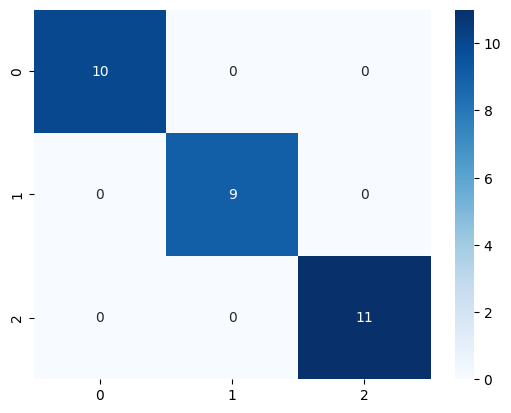

In [ ]:
sns.heatmap(cm,

annot=True,

fmt="d",

cmap="Blues")

plt.show()


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print(accuracy_score(y_test, pred_knn))


1.0


In [ ]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

print(accuracy_score(y_test, pred_tree))


1.0


In [ ]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



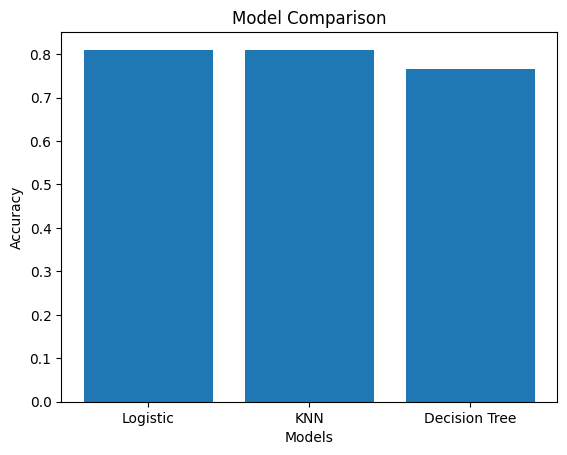

In [ ]:
import matplotlib.pyplot as plt

acc1 = 0.8100558659217877
acc2 = 0.8100558659217877
acc3 = 0.7653631284916201

models = ["Logistic", "KNN", "Decision Tree"]
accuracy = [acc1, acc2, acc3]

plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()